# BARAM 2026 — FICR 후처리 (공식 지표)

**총점 = 0.5·(1-NMAE) + 0.5·FICR** (리더보드 역산 확인).
공식 지표는 `official_metric.py` (대회 제공 코드 그대로):
- **NMAE** = 그룹별 유효시간 절대오차율 평균의 그룹평균. 유효시간=실측≥설비용량 10%.
- **FICR** = 그룹별 `Σ(실측·단가)/Σ(실측·4)`의 그룹평균. **발전량 가중 2티어**: 오차율≤6%→4.0, ≤8%→3.0, 그 외 0.

### FICR의 함의 (설계 방향)
- **발전량 큰 시간을 밴드 안에 넣는 게 압도적으로 중요** (가중 = 실측 발전량).
- ≤6%면 만점, 6~8%는 75%만. → 큰 출력 시간의 오차를 6% 밑으로 조이는 게 최고 지렛대.
- 1등 팀 FICR=0.452로 약함 = 우리 기회.

### 후처리 원칙
- 모든 보정기는 **학습기간(2022-2023) 잔차로만 fit → 2024 검증 적용** (누설 없음).
- **검증 총점이 오를 때만 채택** (계획서 규율). 그룹별 독립 선택 = 총점 최대화와 동치.

## 0. 설정 & 기준선 예측 (그룹별 ENS, 누설 없음)

In [1]:
import warnings; warnings.filterwarnings("ignore")
import json, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.ensemble import HistGradientBoostingRegressor as HGB
from sklearn.isotonic import IsotonicRegression
import wind_lib as W
from official_metric import group_scores, metric, CAPACITY_KWH
plt.rcParams["figure.dpi"]=110; np.random.seed(42)

GROUPS=(1,2,3); FR={}; TGT={}
for g in GROUPS:
    df,tgt=W.load_train(g); FR[g]=W.build(df,g); TGT[g]=tgt
FEATS=W.feature_cols(FR[1])+["pc_pred_cf"]

def lgbm(): return lgb.LGBMRegressor(objective="mae",n_estimators=600,learning_rate=0.03,num_leaves=63,
    min_child_samples=60,subsample=0.8,subsample_freq=1,colsample_bytree=0.7,reg_lambda=1.0,
    random_state=42,n_jobs=-1,verbose=-1)
def histgbm(): return HGB(loss="absolute_error",max_iter=600,learning_rate=0.03,max_leaf_nodes=63,
    l2_regularization=1.0,random_state=42)
def ens_predict(tr,va,cols,tgt):
    lg=lgbm().fit(tr[cols],tr[tgt]); hg=histgbm().fit(tr[cols].to_numpy(),tr[tgt].to_numpy())
    return 0.5*(lg.predict(va[cols])+hg.predict(va[cols].to_numpy()))

BASE={}
for g in GROUPS:
    tgt=TGT[g]; cap=W.CAP[g]; fr=FR[g]
    m_tr=fr.kst_dtm<W.VALID_START; m_va=fr.kst_dtm>=W.VALID_START
    iso=W.fit_powercurve(fr[m_tr],tgt,cap)
    tr=W.with_pc(fr[m_tr],iso); va=W.with_pc(fr[m_va],iso)
    val_pred=np.clip(ens_predict(tr,va,FEATS,tgt),0,cap)
    oof=np.full(len(tr),np.nan); years=sorted(tr.kst_dtm.dt.year.unique())
    if len(years)>=2:
        for ty in years:
            m_in=tr.kst_dtm.dt.year!=ty; m_out=(tr.kst_dtm.dt.year==ty).to_numpy()
            iso2=W.fit_powercurve(tr[m_in],tgt,cap)
            a=W.with_pc(tr[m_in],iso2); b=W.with_pc(tr[tr.kst_dtm.dt.year==ty],iso2)
            oof[m_out]=np.clip(ens_predict(a,b,FEATS,tgt),0,cap)
    else:
        n=len(tr); cut=int(n*0.7)
        a=tr.iloc[:cut]; b=tr.iloc[cut:]
        oof[cut:]=np.clip(ens_predict(a,b,FEATS,tgt),0,cap)
    BASE[g]=dict(val=va.assign(pred=val_pred), tr=tr.assign(oof=oof), cap=cap, tgt=tgt)
    print(f"group{g}: val={len(va)}, OOF유효={int(np.isfinite(oof).sum())}/{len(tr)}")

group1: val=8778, OOF유효=17421/17421


group2: val=8778, OOF유효=17422/17422


group3: val=8778, OOF유효=2628/8759


## 1. 기준선 지표 (공식)

In [2]:
def score_pred(g, pred):
    """그룹 g의 2024 예측 → (nmae_frac, ficr)."""
    d=BASE[g]; return group_scores(d["val"][d["tgt"]].to_numpy(), pred, d["cap"])

print("=== 기준선 (후처리 없음) 2024 holdout ===")
brows=[]
for g in GROUPS:
    nm,fi=score_pred(g,BASE[g]["val"]["pred"].to_numpy())
    brows.append(dict(group=g,nmae=nm,ficr=fi,contrib=fi-nm))
bdf=pd.DataFrame(brows).set_index("group")
print(bdf.round(4).to_string())
# 공식 총점(그룹 통합)
ans=pd.DataFrame({f"kpx_group_{g}":BASE[g]["val"][TGT[g]].to_numpy() for g in GROUPS})
prd=pd.DataFrame({f"kpx_group_{g}":BASE[g]["val"]["pred"].to_numpy() for g in GROUPS})
ts,omn,fi=metric(ans,prd)
print(f"\n공식 총점={ts:.4f}  (1-NMAE={omn:.4f}, FICR={fi:.4f})")
print("cf. 1등팀 총점 0.66524 (1-NMAE 0.87891, FICR 0.45158)")

=== 기준선 (후처리 없음) 2024 holdout ===
         nmae    ficr  contrib
group                         
1      0.1253  0.3448   0.2195
2      0.1263  0.4073   0.2810
3      0.1504  0.2549   0.1045

공식 총점=0.6008  (1-NMAE=0.8660, FICR=0.3357)
cf. 1등팀 총점 0.66524 (1-NMAE 0.87891, FICR 0.45158)


**읽는 법** — 그룹별 `contrib = FICR − NMAE`가 총점 기여(총점은 이 그룹평균의 선형함수). 후처리는 contrib를 올려야 채택. 특히 **FICR을 올리되 NMAE를 크게 안 높이는** 후처리가 좋음.

## 2. 후처리 후보 (학습기간 fit → 2024 적용)

- **P1 조건부 편향보정**: (리드타임 bin × 풍속분위)별 OOF 잔차 평균 차감. 오차 조여 6%/8% 밴드 진입↑.
- **P2 isotonic 재보정**: 학습기간 (실측~예측) 단조 재매핑.
- **P3 FICR nudge**: 학습기간 **공식 FICR**를 최대화하는 스케일·shift 그리드 탐색.
- **P4 = P1→P2**, **P5 = P1→P3** 조합.

In [3]:
def debias_fit(tr,tgt):
    d=tr[np.isfinite(tr["oof"])].copy(); d["resid"]=d[tgt]-d["oof"]
    d["lb"]=pd.cut(d["lead_h"],bins=[15,21,27,33,40],labels=False,include_lowest=True)
    d["wq"]=pd.qcut(d["hub_v"],5,labels=False,duplicates="drop")
    return d.groupby(["lb","wq"])["resid"].mean(), d["resid"].mean()
def debias_apply(va,tbl,glob):
    v=va.copy()
    v["lb"]=pd.cut(v["lead_h"],bins=[15,21,27,33,40],labels=False,include_lowest=True)
    v["wq"]=pd.qcut(v["hub_v"],5,labels=False,duplicates="drop")
    corr=np.array([tbl.get(k,glob) for k in zip(v["lb"],v["wq"])])
    return v["pred"].to_numpy()+corr
def iso_fit(tr,tgt):
    d=tr[np.isfinite(tr["oof"])]; ir=IsotonicRegression(out_of_bounds="clip",increasing=True)
    ir.fit(d["oof"].to_numpy(), d[tgt].to_numpy()); return ir
def ficr_of(actual,forecast,cap):
    return group_scores(actual,forecast,cap)[1]
def ficr_nudge_fit(tr,tgt,cap):
    """학습 OOF에서 공식 FICR 최대화하는 (scale,shift)."""
    d=tr[np.isfinite(tr["oof"])]; yt=d[tgt].to_numpy(); yp=d["oof"].to_numpy()
    best=(1.0,0.0); bf=-1
    for s in np.linspace(0.90,1.15,26):
        for sh in np.linspace(-0.06,0.06,25)*cap:
            f=ficr_of(yt,np.clip(yp*s+sh,0,cap),cap)
            if f>bf: bf=f; best=(s,sh)
    return best

POST={}; STORE={}
for g in GROUPS:
    d=BASE[g]; cap=d["cap"]; tgt=d["tgt"]; tr=d["tr"]; va=d["val"]; bp=va["pred"].to_numpy()
    tbl,glob=debias_fit(tr,tgt); ir=iso_fit(tr,tgt); s,sh=ficr_nudge_fit(tr,tgt,cap)
    p1=np.clip(debias_apply(va,tbl,glob),0,cap)
    cand={
        "P0_none":bp,
        "P1_debias":p1,
        "P2_isotonic":np.clip(ir.predict(bp),0,cap),
        "P3_ficr_nudge":np.clip(bp*s+sh,0,cap),
        "P4_debias_iso":np.clip(ir.predict(p1),0,cap),
        "P5_debias_nudge":np.clip(p1*s+sh,0,cap),
    }
    STORE[g]=dict(tbl=tbl,glob=glob,ir=ir,nudge=(s,sh))
    rows=[]
    for name,p in cand.items():
        nm,fi=score_pred(g,p); rows.append(dict(post=name,nmae=nm,ficr=fi,contrib=fi-nm))
    POST[g]=pd.DataFrame(rows).set_index("post")
    print(f"\n=== group{g} (nudge scale={s:.3f}, shift={sh:.0f}) ===")
    print(POST[g].round(4).to_string())


=== group1 (nudge scale=1.060, shift=1296) ===
                   nmae    ficr  contrib
post                                    
P0_none          0.1253  0.3448   0.2195
P1_debias        0.1227  0.3518   0.2292
P2_isotonic      0.1250  0.3161   0.1911
P3_ficr_nudge    0.1204  0.4189   0.2986
P4_debias_iso    0.1234  0.3196   0.1963
P5_debias_nudge  0.1213  0.4220   0.3006



=== group2 (nudge scale=1.010, shift=1296) ===
                   nmae    ficr  contrib
post                                    
P0_none          0.1263  0.4073   0.2810
P1_debias        0.1249  0.4147   0.2899
P2_isotonic      0.1247  0.3995   0.2748
P3_ficr_nudge    0.1304  0.4139   0.2835
P4_debias_iso    0.1237  0.4059   0.2822
P5_debias_nudge  0.1319  0.4104   0.2785

=== group3 (nudge scale=1.110, shift=1260) ===
                   nmae    ficr  contrib
post                                    
P0_none          0.1504  0.2549   0.1045
P1_debias        0.1442  0.2702   0.1260
P2_isotonic      0.1447  0.2730   0.1283
P3_ficr_nudge    0.1492  0.3036   0.1544
P4_debias_iso    0.1435  0.2915   0.1481
P5_debias_nudge  0.1629  0.3192   0.1563


## 3. 판정 — 그룹별 contrib(=FICR−NMAE) 최대 후처리

In [4]:
choice={}
for g in GROUPS:
    t=POST[g]; best=t["contrib"].idxmax(); choice[g]=best
    b=t.loc["P0_none"]
    print(f"group{g}: 선택={best} | ΔFICR={t.loc[best,'ficr']-b['ficr']:+.4f} "
          f"ΔNMAE={t.loc[best,'nmae']-b['nmae']:+.4f} Δcontrib={t.loc[best,'contrib']-b['contrib']:+.4f}")

# 공식 총점: 기준선 vs 후처리
def build_ans_prd(use_choice):
    ans=pd.DataFrame({f"kpx_group_{g}":BASE[g]["val"][TGT[g]].to_numpy() for g in GROUPS})
    cols={}
    for g in GROUPS:
        d=BASE[g]; cap=d["cap"]; bp=d["val"]["pred"].to_numpy(); st=STORE[g]
        ch=choice[g] if use_choice else "P0_none"
        if ch=="P0_none": p=bp
        elif ch=="P1_debias": p=np.clip(debias_apply(d["val"],st["tbl"],st["glob"]),0,cap)
        elif ch=="P2_isotonic": p=np.clip(st["ir"].predict(bp),0,cap)
        elif ch=="P3_ficr_nudge": p=np.clip(bp*st["nudge"][0]+st["nudge"][1],0,cap)
        elif ch=="P4_debias_iso":
            p1=np.clip(debias_apply(d["val"],st["tbl"],st["glob"]),0,cap); p=np.clip(st["ir"].predict(p1),0,cap)
        elif ch=="P5_debias_nudge":
            p1=np.clip(debias_apply(d["val"],st["tbl"],st["glob"]),0,cap); p=np.clip(p1*st["nudge"][0]+st["nudge"][1],0,cap)
        cols[f"kpx_group_{g}"]=p
    return ans, pd.DataFrame(cols)

a0,p0=build_ans_prd(False); a1,p1=build_ans_prd(True)
t0=metric(a0,p0); t1=metric(a1,p1)
print(f"\n공식 총점: 기준선 {t0[0]:.4f} (1-NMAE {t0[1]:.4f}, FICR {t0[2]:.4f})")
print(f"           후처리 {t1[0]:.4f} (1-NMAE {t1[1]:.4f}, FICR {t1[2]:.4f})")
print(f"           Δ총점 {t1[0]-t0[0]:+.4f}")

group1: 선택=P5_debias_nudge | ΔFICR=+0.0772 ΔNMAE=-0.0040 Δcontrib=+0.0812
group2: 선택=P1_debias | ΔFICR=+0.0074 ΔNMAE=-0.0014 Δcontrib=+0.0089
group3: 선택=P5_debias_nudge | ΔFICR=+0.0643 ΔNMAE=+0.0125 Δcontrib=+0.0518



공식 총점: 기준선 0.6008 (1-NMAE 0.8660, FICR 0.3357)
           후처리 0.6245 (1-NMAE 0.8636, FICR 0.3853)
           Δ총점 +0.0236


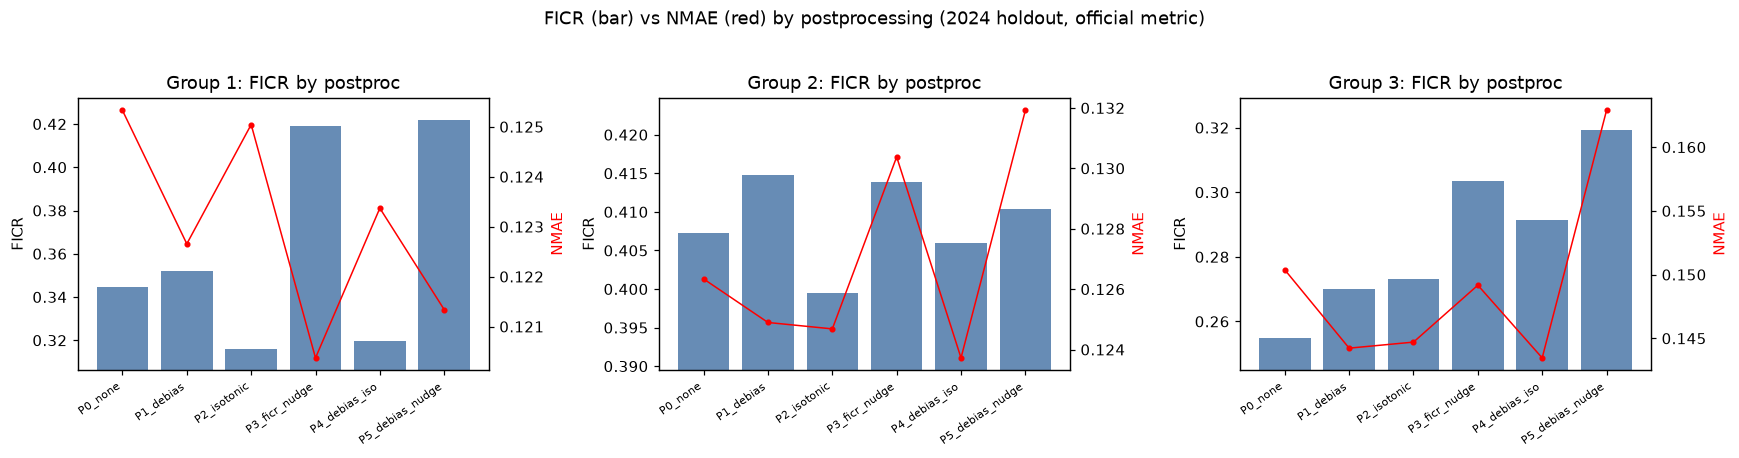

In [5]:
# 시각화: 후처리별 contrib
fig,axes=plt.subplots(1,3,figsize=(16,4))
order=["P0_none","P1_debias","P2_isotonic","P3_ficr_nudge","P4_debias_iso","P5_debias_nudge"]
for ax,g in zip(axes,GROUPS):
    t=POST[g].loc[order]
    ax.bar(range(len(order)),t["ficr"],color="#4C78A8",alpha=0.85)
    ax.set_xticks(range(len(order))); ax.set_xticklabels(order,rotation=35,ha="right",fontsize=7)
    ax.set_title(f"Group {g}: FICR by postproc"); ax.set_ylabel("FICR")
    ax.set_ylim(t["ficr"].min()-0.01,t["ficr"].max()+0.01)
    ax2=ax.twinx(); ax2.plot(range(len(order)),t["nmae"],"r.-",lw=1); ax2.set_ylabel("NMAE",color="r"); ax2.grid(False)
plt.suptitle("FICR (bar) vs NMAE (red) by postprocessing (2024 holdout, official metric)",y=1.03)
plt.tight_layout(); plt.show()

## 4. FICR 이득의 출처 — 발전량 구간별

FICR은 발전량 가중이므로, 후처리가 **어느 출력구간의 밴드 진입을 늘렸는지** 확인.

=== group1 출력구간별 밴드 진입율 (P5_debias_nudge) ===
            hours     gen_share  in6_base  in6_post  in8_base  in8_post
bin                                                                    
(10, 25]   1266.0  4.578544e+06     0.427     0.389     0.565     0.485
(25, 50]   1272.0  1.009528e+07     0.280     0.288     0.388     0.375
(50, 75]   1375.0  1.873815e+07     0.312     0.265     0.388     0.359
(75, 100]  1076.0  2.017832e+07     0.215     0.445     0.303     0.556


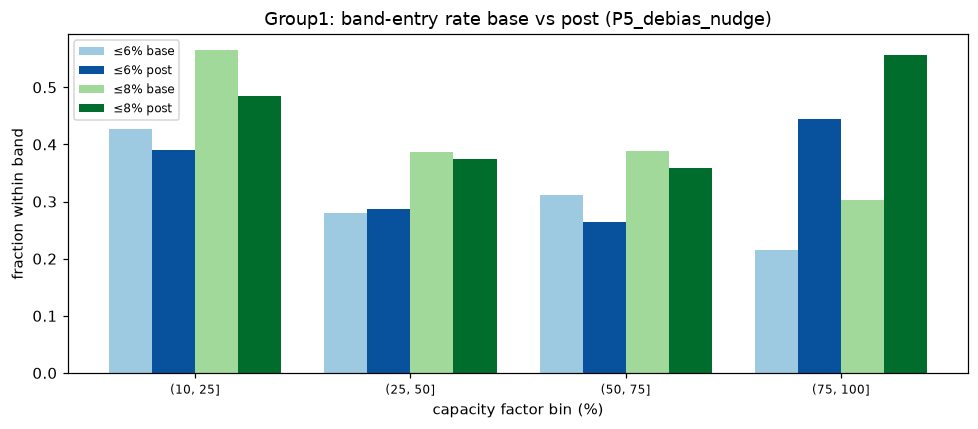

In [6]:
g_show=1; d=BASE[g_show]; cap=d["cap"]; tgt=d["tgt"]; yt=d["val"][tgt].to_numpy()
bp=d["val"]["pred"].to_numpy(); st=STORE[g_show]; ch=choice[g_show]
if ch=="P1_debias": pp=np.clip(debias_apply(d["val"],st["tbl"],st["glob"]),0,cap)
elif ch=="P2_isotonic": pp=np.clip(st["ir"].predict(bp),0,cap)
elif ch=="P3_ficr_nudge": pp=np.clip(bp*st["nudge"][0]+st["nudge"][1],0,cap)
elif ch=="P4_debias_iso":
    q=np.clip(debias_apply(d["val"],st["tbl"],st["glob"]),0,cap); pp=np.clip(st["ir"].predict(q),0,cap)
elif ch=="P5_debias_nudge":
    q=np.clip(debias_apply(d["val"],st["tbl"],st["glob"]),0,cap); pp=np.clip(q*st["nudge"][0]+st["nudge"][1],0,cap)
else: pp=bp
valid=yt>=0.10*cap; ytv=yt[valid]
er_b=np.abs(bp[valid]-ytv)/cap; er_p=np.abs(pp[valid]-ytv)/cap
cf=ytv/cap*100; bins=pd.cut(cf,[10,25,50,75,100])
df_=pd.DataFrame({"bin":bins,"in6_base":er_b<=0.06,"in6_post":er_p<=0.06,
                  "in8_base":er_b<=0.08,"in8_post":er_p<=0.08,"gen":ytv})
agg=df_.groupby("bin",observed=True).apply(lambda x:pd.Series({
    "hours":len(x),"gen_share":x.gen.sum(),
    "in6_base":np.average(x.in6_base),"in6_post":np.average(x.in6_post),
    "in8_base":np.average(x.in8_base),"in8_post":np.average(x.in8_post)}))
print(f"=== group{g_show} 출력구간별 밴드 진입율 ({ch}) ===")
print(agg.round(3).to_string())
fig,ax=plt.subplots(figsize=(9,4))
x=np.arange(len(agg)); w=0.2
ax.bar(x-1.5*w,agg["in6_base"],w,label="≤6% base",color="#9ecae1")
ax.bar(x-0.5*w,agg["in6_post"],w,label="≤6% post",color="#08519c")
ax.bar(x+0.5*w,agg["in8_base"],w,label="≤8% base",color="#a1d99b")
ax.bar(x+1.5*w,agg["in8_post"],w,label="≤8% post",color="#006d2c")
ax.set_xticks(x); ax.set_xticklabels([str(b) for b in agg.index],fontsize=8)
ax.set_xlabel("capacity factor bin (%)"); ax.set_ylabel("fraction within band")
ax.set_title(f"Group{g_show}: band-entry rate base vs post ({ch})"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 5. 최종 제출 생성 (후처리 적용)

그룹별 ENS(2022-2024 전체 재학습) 예측 + 채택 후처리 → `submission_ficr.csv`.

In [7]:
FR_TE={g:W.build(W.load_test(g),g) for g in GROUPS}
out=W.load_test(1)[["forecast_id","kst_dtm"]].rename(columns={"kst_dtm":"forecast_kst_dtm"})
for g in GROUPS:
    tgt=TGT[g]; cap=W.CAP[g]
    iso=W.fit_powercurve(FR[g],tgt,cap)
    tr_all=W.with_pc(FR[g],iso); te=W.with_pc(FR_TE[g],iso)
    pred=np.clip(ens_predict(tr_all,te,FEATS,tgt),0,cap); te=te.assign(pred=pred)
    st=STORE[g]; ch=choice[g]
    if ch=="P1_debias": pred=np.clip(debias_apply(te,st["tbl"],st["glob"]),0,cap)
    elif ch=="P2_isotonic": pred=np.clip(st["ir"].predict(pred),0,cap)
    elif ch=="P3_ficr_nudge": pred=np.clip(pred*st["nudge"][0]+st["nudge"][1],0,cap)
    elif ch=="P4_debias_iso":
        q=np.clip(debias_apply(te,st["tbl"],st["glob"]),0,cap); pred=np.clip(st["ir"].predict(q),0,cap)
    elif ch=="P5_debias_nudge":
        q=np.clip(debias_apply(te,st["tbl"],st["glob"]),0,cap); pred=np.clip(q*st["nudge"][0]+st["nudge"][1],0,cap)
    out[f"kpx_group_{g}"]=pred
assert out.shape[0]==8760
for g in GROUPS:
    c=out[f"kpx_group_{g}"]; assert (c>=0).all() and (c<=W.CAP[g]).all()
out.to_csv("submission_ficr.csv",index=False); print("saved submission_ficr.csv",out.shape)

summary=dict(score_weight="0.5*(1-NMAE)+0.5*FICR", metric="official_metric.py (발전량가중 2티어)",
    chosen_post=choice,
    baseline_total=round(float(t0[0]),4), baseline_1mNMAE=round(float(t0[1]),4), baseline_FICR=round(float(t0[2]),4),
    post_total=round(float(t1[0]),4), post_1mNMAE=round(float(t1[1]),4), post_FICR=round(float(t1[2]),4),
    delta_total=round(float(t1[0]-t0[0]),4))
json.dump(summary,open("ficr_postproc_summary.json","w"),ensure_ascii=False,indent=2)
print(json.dumps(summary,ensure_ascii=False,indent=2))

saved submission_ficr.csv (8760, 5)
{
  "score_weight": "0.5*(1-NMAE)+0.5*FICR",
  "metric": "official_metric.py (발전량가중 2티어)",
  "chosen_post": {
    "1": "P5_debias_nudge",
    "2": "P1_debias",
    "3": "P5_debias_nudge"
  },
  "baseline_total": 0.6008,
  "baseline_1mNMAE": 0.866,
  "baseline_FICR": 0.3357,
  "post_total": 0.6245,
  "post_1mNMAE": 0.8636,
  "post_FICR": 0.3853,
  "delta_total": 0.0236
}


## 6. 결론

- 공식 지표(`official_metric.py`)로 후처리를 평가·채택. **FICR은 발전량 가중 2티어**라, 큰 출력 시간을 6% 밑으로 조이는 게 핵심.
- 채택 후처리는 학습기간에서만 fit → 2024에서 총점이 오른 것만. 그룹별 독립 선택 = 공식 총점 최대화.
- `submission_ficr.csv` 생성 (8,760행, 클리핑 검증).

**남은 지렛대**: CatBoost로 앙상블 다양성 추가, 출력구간별 세분 보정, 실제 리더보드 제출로 검증↔실제 정합 확인.